# Inkriff — Figuras del documento

Este notebook genera **todas las figuras** del documento *Inkriff — Metodología y Resultados*
(`docs/Inkriff_Metodologia_y_Resultados.docx`) a partir de los datos del proyecto, y al final
**verifica que las cifras citadas en el texto salen de esos datos**.

| Figura | Sección del documento | Qué muestra |
|---|---|---|
| 1 | 5.1 Bandas | Número de bandas por subgénero semilla |
| 2 | 5.1 Bandas | Ley de Zipf en tags de MusicBrainz y palabras de sinopsis |
| 3 | 5.2 Libros | Número de libros por categoría semilla |
| 4 | 7.5 Corrección aplicada | Concentración de *hubs* antes y después de la corrección |
| 5 | 8.1 Flujo de inferencia | Diagrama del flujo de la app, del mensaje a las tarjetas |

**Cómo correrlo:** *Entorno de ejecución → Ejecutar todo*. No hay que subir archivos: si el
notebook no encuentra los datos en el repo local, los descarga del repositorio público
[github.com/virycassales/Inkriff](https://github.com/virycassales/Inkriff). Las imágenes se
guardan en la carpeta `figuras/` (PNG a 220 dpi, el tamaño que usa el documento).

**Entradas:** `data/raw/bandas_completo.csv`, `data/processed/libros_con_sinopsis.csv`,
`data/processed/recomendaciones_banda_a_libro.csv`, `data/processed/embeddings_referencia.npz`.


In [1]:
import ast
import io
import os
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from matplotlib.ticker import MaxNLocator
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Paleta del documento: un solo tono (ciruela) para series únicas; gris para "antes"
CIRUELA = "#6B2D5C"   # mismo color que los encabezados del documento
TINTA = "#3D1A35"     # texto principal
APAGADO = "#6E6470"   # ejes y texto secundario
REJILLA = "#E7E1E6"   # rejilla recesiva
GRIS = "#B9B2B8"      # serie de comparación ("antes")
FONDO = "#F6EEF4"     # relleno de cajas del diagrama
DECISION = "#FBE9D7"  # caja de decisión del diagrama

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 9,
    "axes.edgecolor": REJILLA, "axes.labelcolor": APAGADO,
    "xtick.color": APAGADO, "ytick.color": TINTA,
    "axes.spines.top": False, "axes.spines.right": False,
})
DPI = 220
CARPETA = "figuras"
os.makedirs(CARPETA, exist_ok=True)


def guardar(fig, nombre):
    ruta = os.path.join(CARPETA, nombre)
    fig.savefig(ruta, dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Guardada:", ruta)


## Datos

`cargar()` busca cada archivo en el repo local (si el notebook se corre desde `notebooks/` o
desde la raíz) y, si no lo encuentra, lo descarga de GitHub. Los nombres de categorías y
títulos en los CSV vienen sin acentos (así se normalizaron para cruzar tablas); solo para
mostrarlos en las gráficas se les devuelven los acentos con `ACENTOS`.


In [2]:
REPO_RAW = "https://raw.githubusercontent.com/virycassales/Inkriff/main/"


def cargar(ruta_repo):
    """ruta_repo: ruta relativa a la raíz del repo, p. ej. 'data/raw/bandas_completo.csv'."""
    for base in ("", "../"):
        if os.path.exists(base + ruta_repo):
            fuente = base + ruta_repo
            datos = open(fuente, "rb").read()
            break
    else:
        fuente = REPO_RAW + ruta_repo
        respuesta = requests.get(fuente, timeout=60)
        respuesta.raise_for_status()
        datos = respuesta.content
    print(f"{ruta_repo:55s} <- {'GitHub' if fuente.startswith('http') else 'repo local'}")
    if ruta_repo.endswith(".npz"):
        return np.load(io.BytesIO(datos))
    return pd.read_csv(io.BytesIO(datos))


bandas = cargar("data/raw/bandas_completo.csv")
libros = cargar("data/processed/libros_con_sinopsis.csv")
recom_banda_a_libro = cargar("data/processed/recomendaciones_banda_a_libro.csv")
embeddings = cargar("data/processed/embeddings_referencia.npz")
print(f"\nbandas: {bandas.shape} | libros: {libros.shape} | recomendaciones: {recom_banda_a_libro.shape}")
print({k: embeddings[k].shape for k in embeddings.files})

ACENTOS = {
    "Hard Rock / Rock clasico": "Hard Rock / Rock clásico",
    "Fantasia oscura / gotica": "Fantasía oscura / gótica",
    "Romantasy (fantasia romantica)": "Romantasy (fantasía romántica)",
    "Alta fantasia / epica": "Alta fantasía / épica",
    "Gotico clasico / vampiros": "Gótico clásico / vampiros",
    "Fantasia clasica / juvenil": "Fantasía clásica / juvenil",
    "Mitologia (nordica / celta / griega)": "Mitología (nórdica / celta / griega)",
    "Distopia juvenil": "Distopía juvenil",
    "Fantasia de cuento de hadas": "Fantasía de cuento de hadas",
    "Fantasia urbana": "Fantasía urbana",
    "Romance historico / gotico": "Romance histórico / gótico",
    "El Senor de los Anillos": "El Señor de los Anillos",
}
acento = lambda s: ACENTOS.get(s, s)


data/raw/bandas_completo.csv                            <- GitHub


data/processed/libros_con_sinopsis.csv                  <- GitHub


data/processed/recomendaciones_banda_a_libro.csv        <- GitHub


data/processed/embeddings_referencia.npz                <- GitHub

bandas: (81, 10) | libros: (112, 10) | recomendaciones: (405, 6)
{'emb_bandas': (81, 384), 'emb_libros': (112, 384), 'banda_col_means': (81,), 'libro_row_means': (112,), 'global_mean': ()}


In [3]:
def barras_horizontales(conteos, etiqueta_x, alto, nombre_archivo):
    """Barras de una sola serie, ordenadas de mayor a menor, con el valor al final de cada barra."""
    s = conteos.sort_values()
    fig, ax = plt.subplots(figsize=(6.3, alto))
    ax.barh([acento(i) for i in s.index], s.values, color=CIRUELA, height=0.62)
    for y, v in enumerate(s.values):
        ax.text(v + s.max() * 0.012, y, str(v), va="center", fontsize=8, color=TINTA)
    ax.set_xlabel(etiqueta_x)
    ax.xaxis.grid(True, color=REJILLA, lw=0.8)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis="y", length=0)
    ax.set_xlim(0, s.max() * 1.1)
    ax.margins(y=0.01)
    fig.tight_layout()
    guardar(fig, nombre_archivo)


## Figura 1 — Bandas por subgénero (sección 5.1)

Cuenta cuántas de las 81 bandas pertenecen a cada uno de los 24 subgéneros del universo semilla.


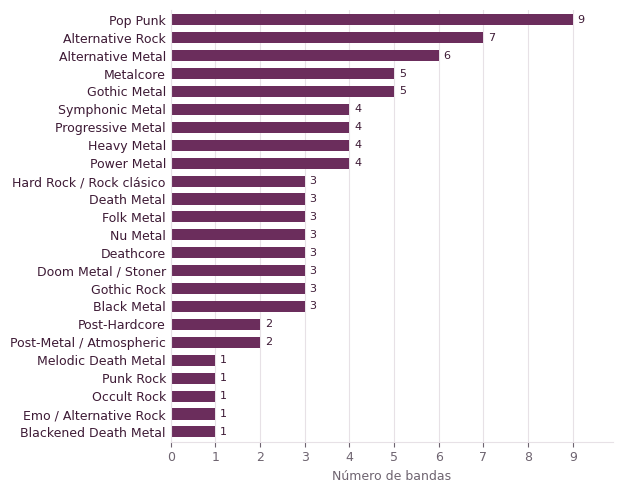

Guardada: figuras/fig1_bandas_por_subgenero.png
81 bandas en 24 subgéneros
Más representados: {'Pop Punk': 9, 'Alternative Rock': 7, 'Alternative Metal': 6}
Subgéneros con una sola banda: 5


In [4]:
por_subgenero = bandas["subgenero_semilla"].value_counts()
barras_horizontales(por_subgenero, "Número de bandas", 5.0, "fig1_bandas_por_subgenero.png")

print(f"{len(bandas)} bandas en {por_subgenero.size} subgéneros")
print("Más representados:", por_subgenero.head(3).to_dict())
print("Subgéneros con una sola banda:", int((por_subgenero == 1).sum()))


## Figura 2 — Ley de Zipf en tags y sinopsis (sección 5.1)

Frecuencia contra rango en escala log-log, con la recta ajustada por mínimos cuadrados. Una
pendiente cercana a −1 es la firma de la Ley de Zipf.

Las palabras de sinopsis se limpian **exactamente igual** que en la ingeniería de variables
(`scripts/rebuild_features_v2.py`): se quitan URLs y referencias tipo `[3]:`, acentos y
puntuación, palabras de 2 letras o menos, *stopwords* (lista completa de scikit-learn + lista
corta en español) y una lista de "ruido editorial" que no describe la trama.


In [5]:
STOPWORDS_ES = {
    "el","la","los","las","de","del","y","a","en","un","una","unos","unas","que",
    "es","por","con","para","su","sus","se","lo","como","mas","pero","o","al",
    "este","esta","estos","estas","ese","esa","esos","esas","ya","muy","entre",
    "sin","sobre","tambien","cuando","donde","porque","desde","hasta","hay",
    "fue","son","ser","han","habia","era","eran","le","les","nos","me","mi",
    "tu","si","no","asi","solo","cada","otro","otra","otros","otras","todo",
    "toda","todos","todas","tras","durante","mientras","aunque","ademas",
}
STOPWORDS = STOPWORDS_ES | set(ENGLISH_STOP_WORDS)
RUIDO_EDITORIAL = {
    "https","http","www","com","org","net","source","openlibrary","googlebooks",
    "google","books","publisher","published","publication","edition","editions",
    "excerpt","isbn","copyright","cover","flap","bestseller","bestselling",
    "york","times","newyork","nytimes","author","authors","press","description",
    "special","note","content","special note",
}


def limpia_texto_v2(t):
    """Misma limpieza que scripts/rebuild_features_v2.py; regresa la lista de palabras."""
    if not isinstance(t, str):
        return []
    t = re.sub(r"https?://\S+", " ", t)          # 1. URLs completas
    t = re.sub(r"\[\d+\]:?", " ", t)            # 2. referencias "[1]:" o "[3]"
    t = unicodedata.normalize("NFKD", t).encode("ascii", "ignore").decode("ascii")
    t = re.sub(r"[^a-z ]", " ", t.lower())
    return [w for w in t.split()
            if len(w) > 2 and w not in STOPWORDS and w not in RUIDO_EDITORIAL]


conteo_tags = Counter(tag for lista in bandas["tags_top"] for tag in ast.literal_eval(lista))
sinopsis = libros["sinopsis"].fillna("").str.strip()
sinopsis = sinopsis[sinopsis.str.len() > 0]
conteo_palabras = Counter(p for texto in sinopsis for p in limpia_texto_v2(texto))
print(f"Tags distintos: {len(conteo_tags)} | libros con sinopsis: {len(sinopsis)} | palabras distintas: {len(conteo_palabras)}")


Tags distintos: 111 | libros con sinopsis: 97 | palabras distintas: 3593


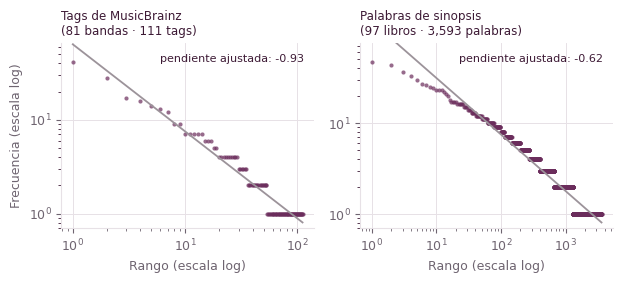

Guardada: figuras/fig2_ley_de_zipf.png
Pendiente tags: -0.93 | pendiente palabras: -0.62 (Zipf ideal = -1)
Palabras que aparecen una sola vez: 64.1%


In [6]:
fig, axs = plt.subplots(1, 2, figsize=(6.3, 2.9))
pendientes = {}
paneles = [
    (f"Tags de MusicBrainz\n({len(bandas)} bandas · {len(conteo_tags)} tags)", "tags", conteo_tags),
    (f"Palabras de sinopsis\n({len(sinopsis)} libros · {len(conteo_palabras):,} palabras)", "palabras", conteo_palabras),
]
for ax, (titulo, clave, conteo) in zip(axs, paneles):
    frec = np.array(sorted(conteo.values(), reverse=True), dtype=float)
    rango = np.arange(1, len(frec) + 1)
    pendiente, intercepto = np.polyfit(np.log10(rango), np.log10(frec), 1)
    pendientes[clave] = pendiente
    ax.loglog(rango, frec, "o", ms=3, color=CIRUELA, alpha=0.7, mec="none")
    ax.loglog(rango, 10 ** intercepto * rango ** pendiente, "-", color="#9C939A", lw=1.3)
    ax.text(0.96, 0.94, f"pendiente ajustada: {pendiente:.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color=TINTA)
    ax.set_title(titulo, fontsize=8.6, color=TINTA, loc="left")
    ax.set_xlabel("Rango (escala log)")
    ax.grid(True, which="major", color=REJILLA, lw=0.7)
    ax.tick_params(axis="y", colors=APAGADO)
    ax.set_ylim(0.7, frec.max() * 1.6)
axs[0].set_ylabel("Frecuencia (escala log)")
fig.tight_layout()
guardar(fig, "fig2_ley_de_zipf.png")

frec_palabras = np.array(list(conteo_palabras.values()))
proporcion_una_vez = (frec_palabras == 1).mean()
print(f"Pendiente tags: {pendientes['tags']:.2f} | pendiente palabras: {pendientes['palabras']:.2f} (Zipf ideal = -1)")
print(f"Palabras que aparecen una sola vez: {proporcion_una_vez:.1%}")


## Figura 3 — Libros por categoría (sección 5.2)

Cuenta cuántos de los 112 libros pertenecen a cada una de las 15 categorías del universo semilla.


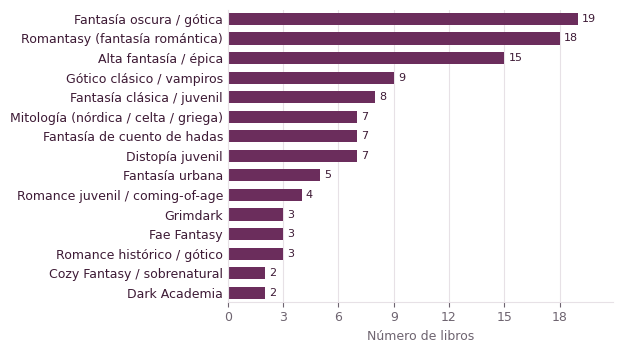

Guardada: figuras/fig3_libros_por_categoria.png
112 libros en 15 categorías
Top 3: {'Fantasia oscura / gotica': 19, 'Romantasy (fantasia romantica)': 18, 'Alta fantasia / epica': 15} -> 52 libros (46%)


In [7]:
por_categoria = libros["categoria_semilla"].value_counts()
barras_horizontales(por_categoria, "Número de libros", 3.6, "fig3_libros_por_categoria.png")

top3 = por_categoria.head(3)
print(f"{len(libros)} libros en {por_categoria.size} categorías")
print("Top 3:", top3.to_dict(), f"-> {top3.sum()} libros ({top3.sum() / len(libros):.0%})")


## Figura 4 — Concentración de *hubs* antes y después (sección 7.5)

- **Antes:** similitud coseno con los embeddings sin corregir y **todos** los libros como
  candidatos (incluidos los 15 sin sinopsis), igual que en la primera corrida del modelado.
  Como los embeddings están normalizados, `emb_libros @ emb_bandas.T` es la matriz de cosenos.
- **Después:** el top-5 final por banda (`recomendaciones_banda_a_libro.csv`), con la
  corrección de hubness y sin los libros que no tienen sinopsis.

Se grafican los 6 libros más repetidos "antes" más los que entran al top-4 "después".


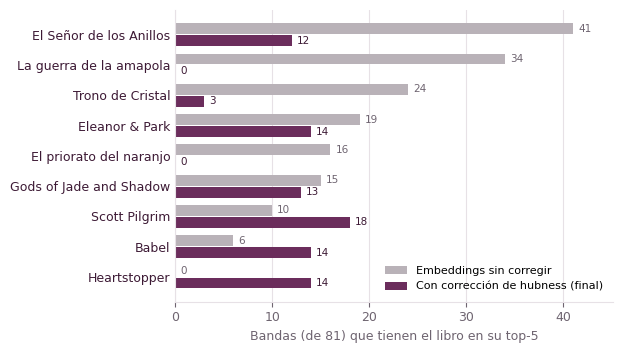

Guardada: figuras/fig4_hubs_antes_despues.png
El Señor de los Anillos      antes 41 -> después 12
La guerra de la amapola      antes 34 -> después  0
Trono de Cristal             antes 24 -> después  3
Eleanor & Park               antes 19 -> después 14
El priorato del naranjo      antes 16 -> después  0
Gods of Jade and Shadow      antes 15 -> después 13
Scott Pilgrim                antes 10 -> después 18
Babel                        antes  6 -> después 14
Heartstopper                 antes  0 -> después 14


In [8]:
sim_sin_corregir = embeddings["emb_libros"] @ embeddings["emb_bandas"].T   # (112 libros, 81 bandas)
top5_por_banda = np.argsort(-sim_sin_corregir, axis=0)[:5]
antes = Counter(libros["titulo_buscado"].iloc[i] for columna in top5_por_banda.T for i in columna)
top1_antes = Counter(libros["titulo_buscado"].iloc[np.argmax(sim_sin_corregir[:, j])]
                     for j in range(sim_sin_corregir.shape[1]))
despues = recom_banda_a_libro["libro_recomendado"].value_counts()

seleccion = [t for t, _ in antes.most_common(6)]
seleccion += [t for t in despues.index[:4] if t not in seleccion]
v_antes = np.array([antes.get(t, 0) for t in seleccion])
v_despues = np.array([despues.get(t, 0) for t in seleccion])
orden = np.argsort(v_antes)[::-1]
seleccion, v_antes, v_despues = [seleccion[i] for i in orden], v_antes[orden], v_despues[orden]

fig, ax = plt.subplots(figsize=(6.3, 3.6))
y = np.arange(len(seleccion))[::-1]
alto = 0.36
ax.barh(y + alto / 2 + 0.02, v_antes, height=alto, color=GRIS, label="Embeddings sin corregir")
ax.barh(y - alto / 2 - 0.02, v_despues, height=alto, color=CIRUELA, label="Con corrección de hubness (final)")
for yy, a, d in zip(y, v_antes, v_despues):
    ax.text(a + 0.5, yy + alto / 2 + 0.02, str(a), va="center", fontsize=7.5, color=APAGADO)
    ax.text(d + 0.5, yy - alto / 2 - 0.02, str(d), va="center", fontsize=7.5, color=TINTA)
ax.set_yticks(y)
ax.set_yticklabels([acento(t) for t in seleccion])
ax.tick_params(axis="y", length=0)
ax.set_xlabel(f"Bandas (de {len(bandas)}) que tienen el libro en su top-5")
ax.xaxis.grid(True, color=REJILLA, lw=0.8)
ax.set_axisbelow(True)
ax.legend(loc="lower right", frameon=False, fontsize=8)
ax.set_xlim(0, v_antes.max() * 1.1)
fig.tight_layout()
guardar(fig, "fig4_hubs_antes_despues.png")

for t, a, d in zip(seleccion, v_antes, v_despues):
    print(f"{acento(t):28s} antes {a:2d} -> después {d:2d}")


## Figura 5 — Flujo de inferencia (sección 8.1)

Diagrama (no depende de datos) de lo que hace la app desde que el usuario escribe hasta que
recibe las tarjetas. La rama "No" corresponde a la búsqueda en vivo para bandas o libros que
no están en el catálogo.


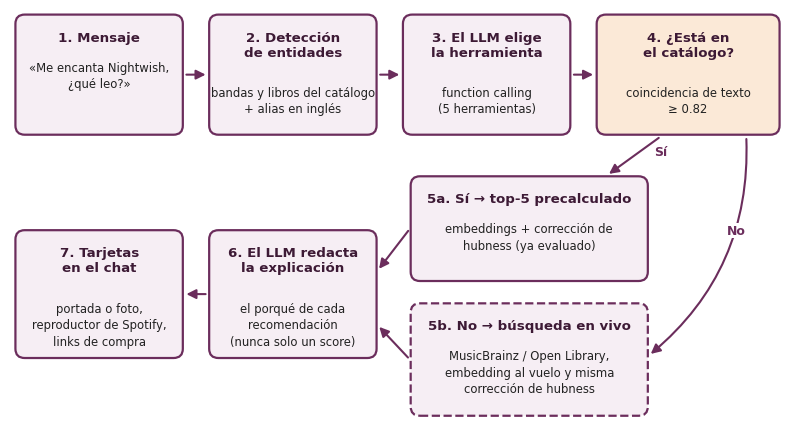

Guardada: figuras/fig5_flujo_inferencia.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5.4))
ax.set_xlim(0, 100)
ax.set_ylim(0, 54)
ax.axis("off")


def caja(x, y, ancho, alto, titulo, cuerpo, relleno=FONDO, linea="-"):
    ax.add_patch(FancyBboxPatch((x, y), ancho, alto, boxstyle="round,pad=0.3,rounding_size=1.2",
                                fc=relleno, ec=CIRUELA, lw=1.6, ls=linea))
    ax.text(x + ancho / 2, y + alto - 1.8, titulo, ha="center", va="top", fontsize=9.6,
            fontweight="bold", color=TINTA, linespacing=1.2)
    lineas_titulo = titulo.count("\n") + 1
    ax.text(x + ancho / 2, y + alto - 2.4 - 3.3 * lineas_titulo, cuerpo, ha="center", va="top",
            fontsize=8.4, color="#222222", linespacing=1.35)


def flecha(x1, y1, x2, y2, etiqueta=None, dx=0, dy=0, curva=0):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=14,
                                 color=CIRUELA, lw=1.5, connectionstyle=f"arc3,rad={curva}"))
    if etiqueta:
        ax.text((x1 + x2) / 2 + dx, (y1 + y2) / 2 + dy, etiqueta, fontsize=9, fontweight="bold",
                color=CIRUELA, ha="center", va="center", bbox=dict(fc="white", ec="none", pad=1))


ancho, alto, fila1 = 21, 15, 38
caja(1, fila1, ancho, alto, "1. Mensaje", "«Me encanta Nightwish,\n¿qué leo?»")
caja(26, fila1, ancho, alto, "2. Detección\nde entidades", "bandas y libros del catálogo\n+ alias en inglés")
caja(51, fila1, ancho, alto, "3. El LLM elige\nla herramienta", "function calling\n(5 herramientas)")
caja(76, fila1, ancho + 2, alto, "4. ¿Está en\nel catálogo?", "coincidencia de texto\n≥ 0.82", relleno=DECISION)
for xa, xb in [(22.4, 25.6), (47.4, 50.6), (72.4, 75.6)]:
    flecha(xa, fila1 + alto / 2, xb, fila1 + alto / 2)
caja(52, 19, 30, 13, "5a. Sí → top-5 precalculado", "embeddings + corrección de\nhubness (ya evaluado)")
caja(52, 1.5, 30, 14, "5b. No → búsqueda en vivo",
     "MusicBrainz / Open Library,\nembedding al vuelo y misma\ncorrección de hubness", linea="--")
caja(26, 9, ancho, alto + 1, "6. El LLM redacta\nla explicación", "el porqué de cada\nrecomendación\n(nunca solo un score)")
caja(1, 9, ancho, alto + 1, "7. Tarjetas\nen el chat", "portada o foto,\nreproductor de Spotify,\nlinks de compra")
flecha(84, fila1 - 0.5, 77, 32.4, "Sí", dx=3.5, dy=0.5)
flecha(95, fila1 - 0.5, 82.4, 9, "No", dx=5, dy=2, curva=-0.25)
flecha(51.6, 25.5, 47.4, 20)
flecha(51.6, 8.5, 47.4, 13)
flecha(25.6, 17, 22.4, 17)
guardar(fig, "fig5_flujo_inferencia.png")


## Verificación de las cifras citadas en el documento

Cada `assert` comprueba una cifra que aparece en el texto del documento. Si los datos
cambian y alguna deja de cumplirse, esta celda falla y dice cuál hay que actualizar.


In [10]:
verificaciones = [
    ("5.1  bandas / subgéneros", (len(bandas), por_subgenero.size), (81, 24)),
    ("5.1  tags distintos", len(conteo_tags), 111),
    ("5.3  libros con sinopsis", len(sinopsis), 97),
    ("5.3  palabras distintas tras limpieza", len(conteo_palabras), 3593),
    ("Fig 2 pendiente tags", round(pendientes["tags"], 2), -0.93),
    ("Fig 2 pendiente palabras", round(pendientes["palabras"], 2), -0.62),
    ("Fig 2 palabras con una sola aparición", round(proporcion_una_vez * 100), 64),
    ("Fig 3 libros en las 3 categorías principales", int(top3.sum()), 52),
    ("7.4  El Señor de los Anillos en top-5 (antes)", antes["El Senor de los Anillos"], 41),
    ("7.4  La guerra de la amapola en top-5 (antes)", antes["La guerra de la amapola"], 34),
    ("7.5  libro top-1 más repetido (antes)", top1_antes.most_common(1)[0][1], 31),
    ("7.5  libro más repetido en el top-5 final", int(despues.max()), 18),
    ("Fig 4 El Señor de los Anillos (después)", int(despues.get("El Senor de los Anillos", 0)), 12),
]
for nombre, obtenido, esperado in verificaciones:
    estado = "OK " if obtenido == esperado else "NO "
    print(f"{estado} {nombre:48s} obtenido={obtenido}  documento={esperado}")
assert all(o == e for _, o, e in verificaciones), "Alguna cifra del documento no coincide con los datos"
print("\nTodas las cifras del documento coinciden con los datos.")


OK  5.1  bandas / subgéneros                         obtenido=(81, 24)  documento=(81, 24)
OK  5.1  tags distintos                              obtenido=111  documento=111
OK  5.3  libros con sinopsis                         obtenido=97  documento=97
OK  5.3  palabras distintas tras limpieza            obtenido=3593  documento=3593
OK  Fig 2 pendiente tags                             obtenido=-0.93  documento=-0.93
OK  Fig 2 pendiente palabras                         obtenido=-0.62  documento=-0.62
OK  Fig 2 palabras con una sola aparición            obtenido=64  documento=64
OK  Fig 3 libros en las 3 categorías principales     obtenido=52  documento=52
OK  7.4  El Señor de los Anillos en top-5 (antes)    obtenido=41  documento=41
OK  7.4  La guerra de la amapola en top-5 (antes)    obtenido=34  documento=34
OK  7.5  libro top-1 más repetido (antes)            obtenido=31  documento=31
OK  7.5  libro más repetido en el top-5 final        obtenido=18  documento=18
OK  Fig 4 El Señor de 

## Descargar las figuras (solo en Colab)


In [11]:
import shutil

shutil.make_archive("figuras_inkriff", "zip", CARPETA)
try:
    from google.colab import files
    files.download("figuras_inkriff.zip")
except ImportError:
    print(f"Las figuras están en la carpeta {CARPETA}/ (y comprimidas en figuras_inkriff.zip)")


Las figuras están en la carpeta figuras/ (y comprimidas en figuras_inkriff.zip)
